# Eclipsing binaries (EBs)

This notebook can be used to have a quicklook at the that product for the simulations.

In [40]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [116]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PlatoSim libraries
import platosim.plot      as pt
import platosim.mocka     as mk
import platosim.utilities as ut
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

from IPython.display import display, HTML
display(HTML("<style>.container {width:70% !important; }</style>"))

In [112]:
path = os.getenv('PLATO_WORKDIR') + 'binary'
fdir = f'{path}/plots'
idir = f'{path}/input'

---
## 1. Stellar catalogue
---

In [101]:
# Load PLATO-CS catalogue
df = pd.read_feather(f'{path}/../mocka/input/starcat_GaiaDR3_PlatoCS.ftr')
# df = pd.read_feather(f'{path}/../mocka/input/starcat_GaiaDR3_PlatoCS.ftr')
df.gaiaDR3 = df.gaiaDR3.astype(float)
df.head()

,starID,gaiaDR3,ra,dec,Gmag,BP_RP,Ag,plx,plx_err,pmra,...,spec,evol,variable,class,Pmag,PBmag,PRmag,ncams,d,Mg
0,1041692,4.677206e+18,69.189319,-62.077491,1.958775,3.770394,NaN,NaN,NaN,NaN,...,unknown,<NA>,NOT_AVAILABLE,,1.448518,3.785839,0.560105,6,NaN,NaN
1,1468318,5.300300e+18,139.272369,-59.275176,2.213786,0.552959,NaN,NaN,NaN,NaN,...,unknown,<NA>,NOT_AVAILABLE,,2.037026,2.179420,1.859075,6,NaN,NaN
2,3190904,5.605797e+18,111.023738,-29.303083,2.450408,0.339532,NaN,NaN,NaN,NaN,...,unknown,<NA>,NOT_AVAILABLE,,2.335989,2.418159,2.227041,6,NaN,NaN
3,3166027,5.610442e+18,105.429755,-27.934809,2.760549,1.768627,NaN,2.508533,0.158969,-5.714241,...,K,<NA>,NOT_AVAILABLE,,2.359611,3.053957,1.819715,6,398.639399,-5.242352
4,53517,4.676528e+18,63.606558,-62.473613,3.125906,1.148879,NaN,20.343132,0.185911,45.068559,...,G,<NA>,NOT_AVAILABLE,,2.816642,3.176923,2.448798,6,49.156640,-0.332005


In [93]:
# Load Luc's binary table
dt = pd.read_csv(f'{path}/table_OBAF_EB_catalogue.csv')
dt.head()

,TIC,TWOMASS,ra,dec,plx,e_plx,gallong,gallat,eclong,eclat,...,duplicate_group,duplicate_master,result_flag,r_max,r_min,t_tot,g_modes,p_modes,near_harm,f_cross
0,80452824,00474953-4619469,11.956440,-46.329703,3.235930,0.026254,304.826864,-70.785257,346.958328,-46.099118,...,-1,-1,0,0.051183,0.020747,27.354240,0.0,0.0,0.0,0.0
1,100098592,01362236-4653345,24.093206,-46.892909,1.974850,0.030529,281.782727,-68.347237,356.837939,-51.333785,...,-1,-1,2,0.594937,0.042295,53.548363,NaN,NaN,NaN,NaN
2,229102235,02015699-4617594,30.487428,-46.299827,0.663769,0.016198,271.563655,-66.300566,3.270109,-53.392200,...,-1,-1,0,0.380321,0.249424,20.228974,0.0,0.0,0.0,0.0
3,160221258,01514453-4628010,27.935542,-46.466974,0.481364,0.024246,275.282322,-67.291195,0.722050,-52.514421,...,-1,-1,0,0.225754,0.097502,51.604357,0.0,0.0,1.0,0.0
4,142164033,02280569-4752269,37.023734,-47.874156,0.482626,0.019087,267.154177,-61.988273,8.029741,-57.259921,...,-1,-1,0,0.475036,0.254206,21.604095,0.0,0.0,0.0,0.0


<IPython.core.display.Javascript object>


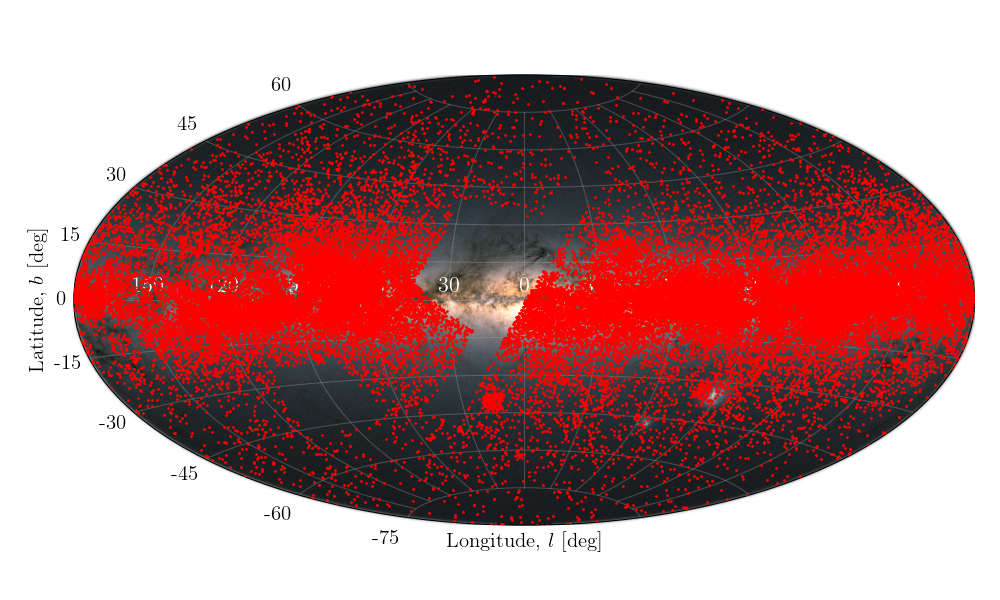

In [94]:
fig, ax = pt.drawStarsInSkyAitoff(dt.ra, dt.dec, figsize=(10,6))

In [102]:
# Cross-match catalogue
dt0 = dt[dt['GAIA_DR3'].isin(df['gaiaDR3'])].sort_values(by=['GAIA_DR3']).reset_index(drop=True)
df0 = df[df['gaiaDR3'].isin(dt['GAIA_DR3'])].sort_values(by=['gaiaDR3']).reset_index(drop=True)
# dt0 = dt[dt['GAIA_DR3'].isin(df['source_gaia_dr3'])].sort_values(by=['GAIA_DR3']).reset_index(drop=True)
# df0 = df[df['source_gaia_dr3'].isin(dt['GAIA_DR3'])].sort_values(by=['source_gaia_dr3']).reset_index(drop=True)

<IPython.core.display.Javascript object>


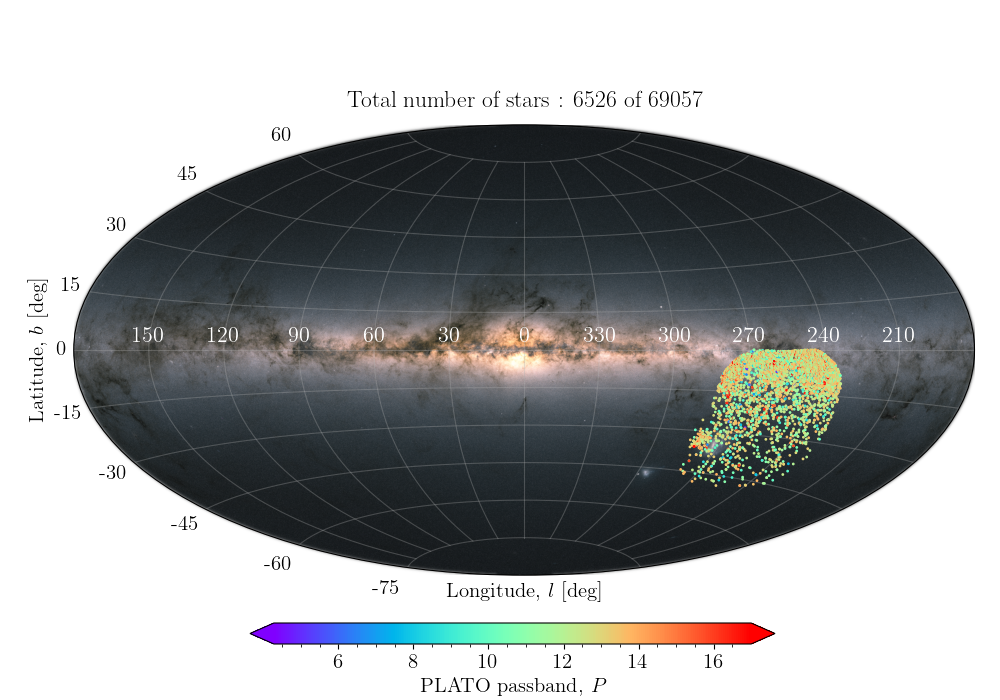

In [104]:
fig, ax = pt.drawStarsInSkyAitoff(df0.ra, df0.dec, df0.Gmag, figsize=(10,7),
                                  title=f'Total number of stars : {df0.shape[0]} of {dt.shape[0]}')

Before cuts: [4336, 1688, 186, 316]
After  cuts: [4134, 1619, 178, 304]


<IPython.core.display.Javascript object>


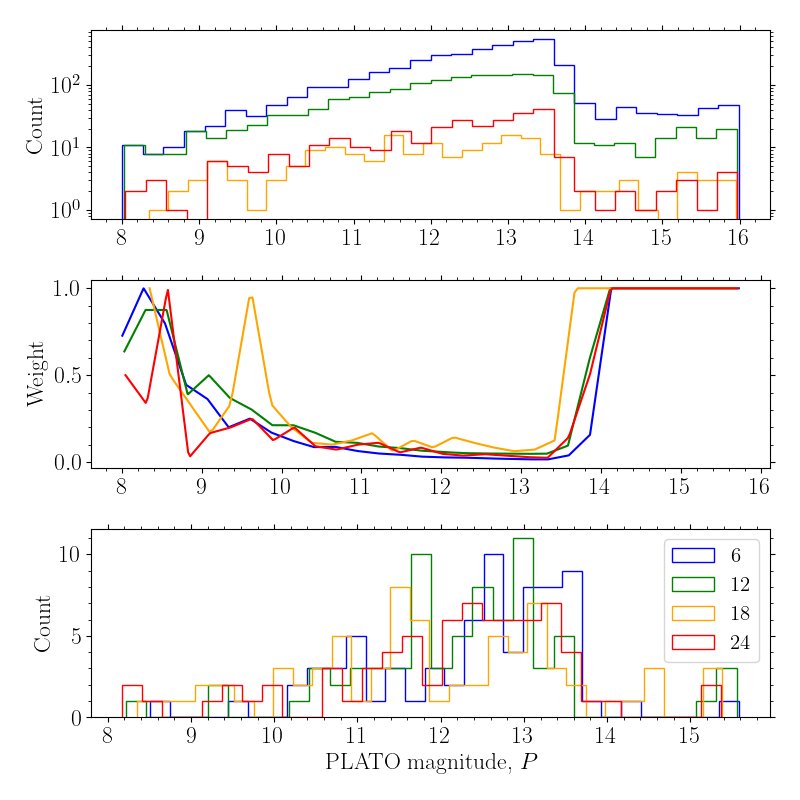

In [105]:
# Select catalogue EBs
nstars = int(295/4)

# All stars
ds = df0
n_all = [ds[ds.ncams == i].shape[0] for i in [6,12,18,24]]
print('Before cuts:', n_all)

# Perform cuts
ds = ds[(ds.Pmag > 8) & (ds.Pmag < 16)]
n_all = [ds[ds.ncams == i].shape[0] for i in [6,12,18,24]]
print('After  cuts:', n_all)

# Fetch sample
ds = mk.fetch_sample(ds, nstars, seed=None, max_mag=14, max_weight=1)

<IPython.core.display.Javascript object>


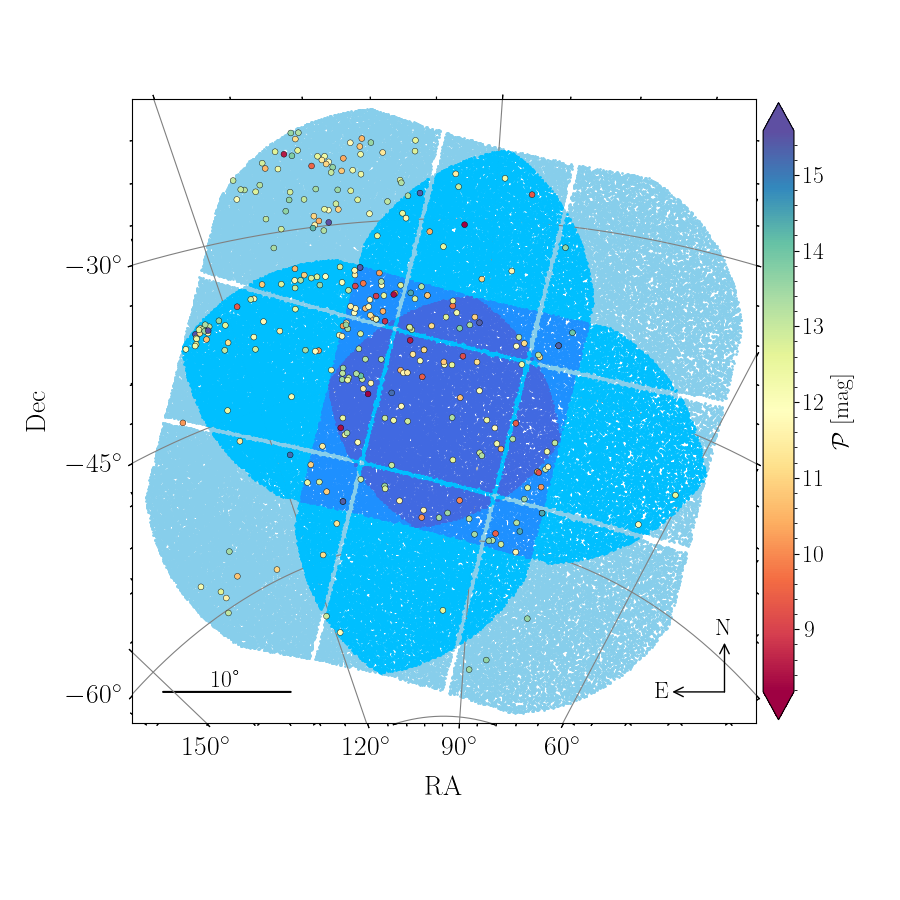

In [111]:
fig, ax = pt.plotPlatoFOV('LOPS2', raStars=ds.ra, decStars=ds.dec, c=ds.Pmag, s=70, lw=0.3, 
                          ncamStars=True, clabel=r'$\mathcal{P}$ [mag]', figsize=(9,9))
fig.savefig(f'{fdir}/starcat_sky_EBs.png', bbox_inches='tight', dpi=200)

In [114]:
# Create target catalogue
ds.reset_index(drop=True, inplace=True)
ds.to_feather(f'{idir}/starcat_GaiaDR3_PlatoCS_EB_targets.ftr')

In [117]:
# Create contaminant catalogue
dc = ut.getContaminants(ds, df, column='gaiaDR3')
dc.to_feather(f'{idir}/starcat_GaiaDR3_PlatoCS_EB_contaminants.ftr')

100%|██████████████████████████████████████████████████| 292/292 [00:08<00:00, 3


In [121]:
ds.columns[1:]

Index(['gaiaDR3', 'ra', 'dec', 'Gmag', 'BP_RP', 'Ag', 'plx', 'plx_err', 'pmra',
       'pmdec', 'ruwe', 'Z', 'Z_low', 'Z_upp', 'logg', 'logg_low', 'logg_upp',
       'Teff', 'Teff_low', 'Teff_upp', 'R', 'R_low', 'R_upp', 'M', 'M_low',
       'M_upp', 'L', 'L_low', 'L_upp', 'S', 'S_err', 'spec', 'evol',
       'variable', 'class', 'Pmag', 'PBmag', 'PRmag', 'ncams', 'd', 'Mg'],
      dtype='object')

---
## Single mode
---

In [14]:
path = '/lhome/nicholas/software/workdir/cs-binary/test_hdf5'
# filename = f"{path}/000000002/000000002_Ncam3.1_Q5.hdf5"
filename = f"{path}/000000004/000000004_Ncam1.1_Q3.hdf5"
# filename = f"{path}/000000012/000000012_Ncam2.1_Q1.hdf5"

# path = '/lhome/nicholas/software/workdir/cs-planet/test_hdf5'
# filename = f"{path}/000000001/000000001_Ncam1.5_Q1.hdf5"

# path = '/lhome/nicholas/software/workdir/cs-exomoon/test_hdf5'
# filename = f"{path}/000000001/000000001_Ncam1.1_Q1.hdf5"

# Load a single mission quarter light curve
lc = LightCurve(filename, mode="single")
ds = lc.star()
ds

ID                     4
PIC        2604625000144
ra            104.068602
dec           -41.009066
mag              12.3222
group                  1
camera                 1
quarter                3
ccd                    4
xCCD         3552.832257
yCCD         4164.140316
rOA            14.861845
xFP             7.525474
yFP            65.250981
ncon                   1
SPR             0.000758
Name: 0, dtype: object

<IPython.core.display.Javascript object>


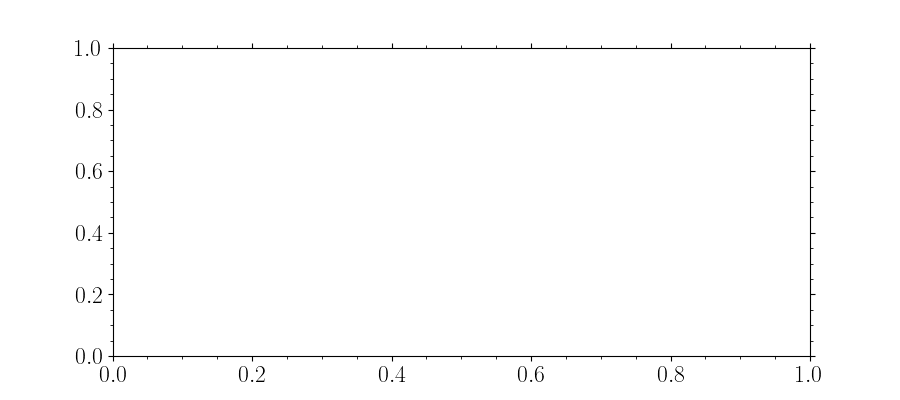

AttributeError: 'NoneType' object has no attribute 'time'

In [9]:
# Show in the injected variability
dv = lc.varsource()
fig, ax = plt.subplots(1, 1, figsize=(9,4))
ax.plot(dv.time/86400, dv.flux, 'k-', lw=0.5)
ax.set_xlabel('Time [d]')
ax.set_ylabel('Normalised flux')
ax.set_xlim(dv.time.min()/86400, dv.time.max()/86400)
plt.tight_layout();

<IPython.core.display.Javascript object>


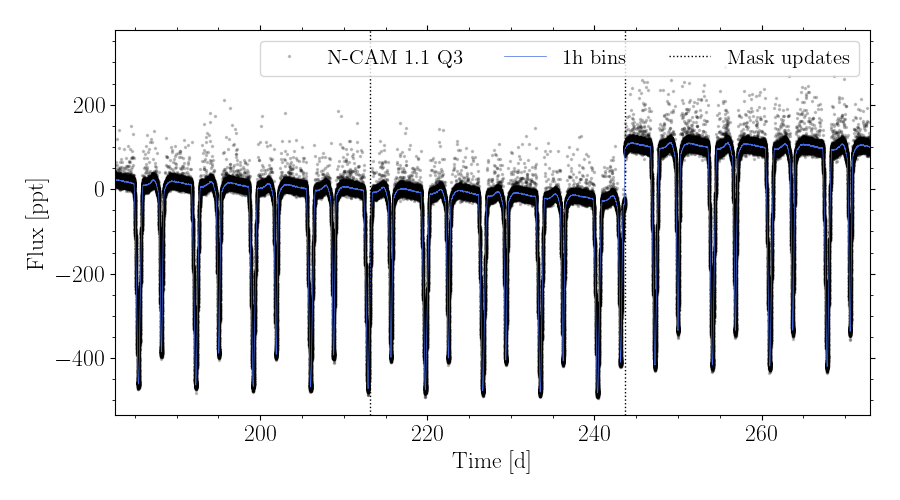

In [10]:
# Show a quarter light curve
lc.plot(flux_unit='ppt', median_filter=1, input_model=False, figsize=(9,5));

### *Test post-processing*

<IPython.core.display.Javascript object>


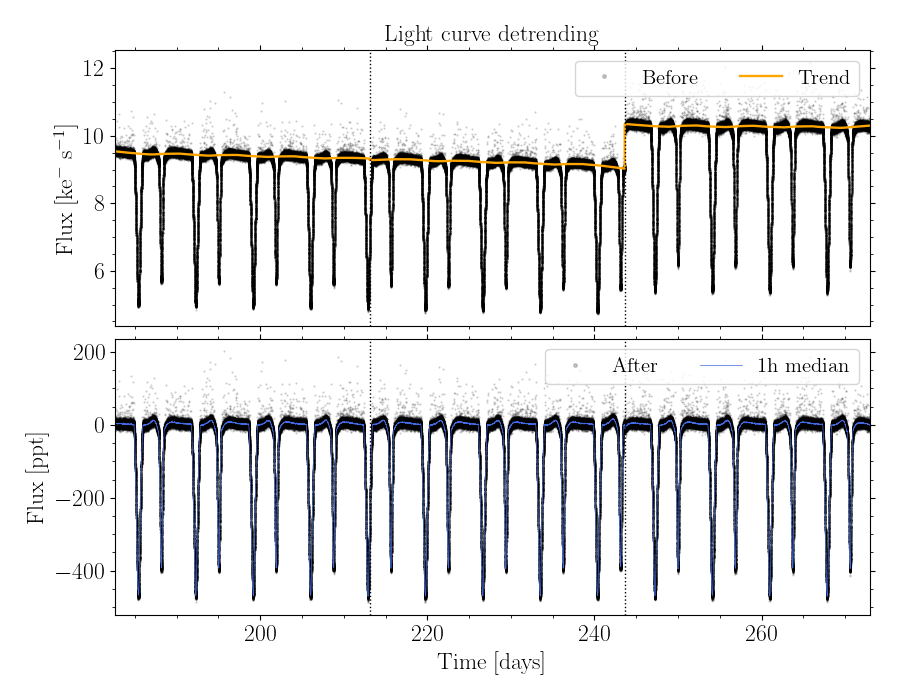

In [15]:
# df = lc.detrend(model='wotan', segments=True, replace=True, plot=True)

df = lc.detrend(model='lowess', segments=True, replace=False, plot=False)
fig, ax = lc.plot_detrend(df)
fig.savefig(f'{path}/../detrending.png', bbox_inches='tight', dpi=200)

<IPython.core.display.Javascript object>


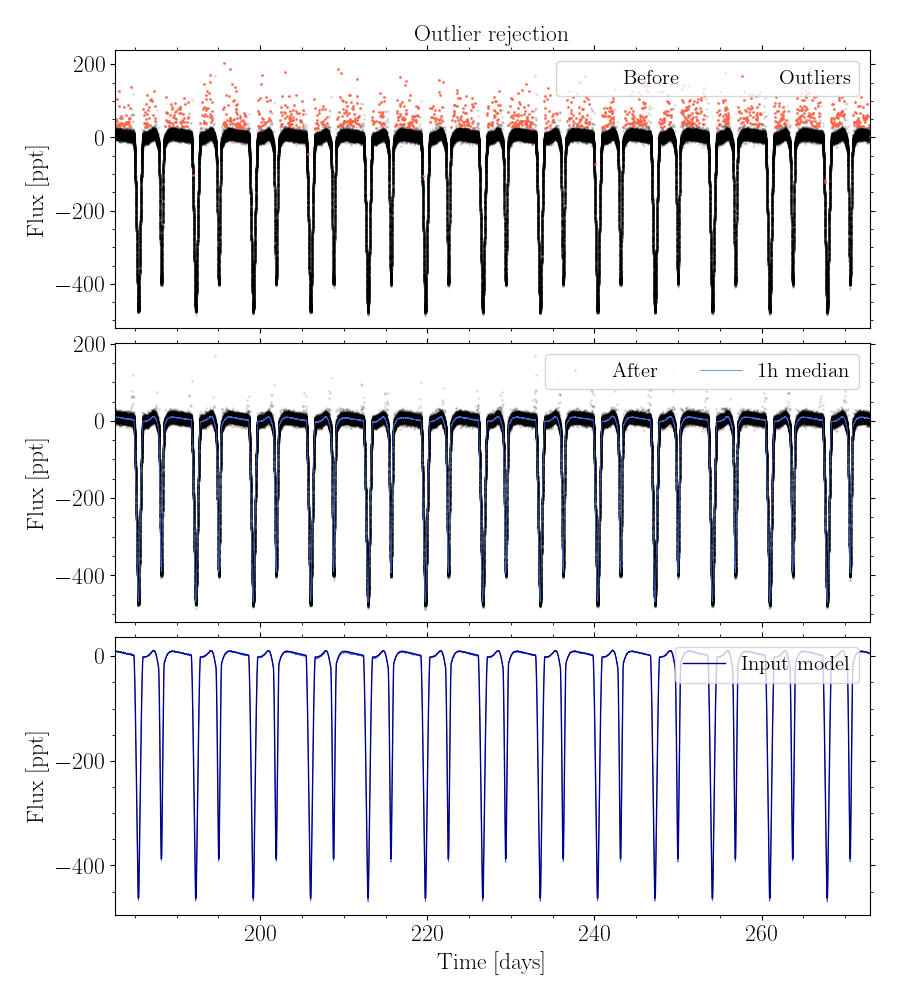

In [160]:
# Remove outliers (due to photon noise and cosmic ray hits)
df = lc.clip(model='wotan', sigma_lower=6, sigma_upper=3, flux_unit='ppt', plot=True)

In [184]:
# Stitch the segments (only needed if detrending leaves big jumps)
# df = lc.stitch(column='flux_detrend', method='lowess', gapsize=0.1, segment=5, plot=True)

---
## Multi mode
---

In [74]:
# path = '/lhome/nicholas/software/workdir/cs-binary/test_vsc/000000001'

# path = '/lhome/nicholas/software/workdir/cs-planet/tests_vsc/000000001'

path = '/lhome/nicholas/software/workdir/cs-exomoon/test_vsc'
star = '000000002'

# In multi mode we parse the entire directory of files
lcs = LightCurve(f'{path}/{star}', mode="multi")

In [83]:
lcs = LightCurve(f'{path}', mode="multi")

<bound method LightCurve.files of <platosim.lightcurve.LightCurve object at 0x7f4814251d90>>

In [63]:
lcs.unpack()

### *Use multi-mode as single-mode*

In [75]:
# Fetch files in folder
filenames = lcs.files(suffix='ftr')
filenames[:3]

['/lhome/nicholas/software/workdir/cs-exomoon/test_vsc/000000002/000000002_Ncam1.1_Q1.ftr',
 '/lhome/nicholas/software/workdir/cs-exomoon/test_vsc/000000002/000000002_Ncam1.1_Q2.ftr',
 '/lhome/nicholas/software/workdir/cs-exomoon/test_vsc/000000002/000000002_Ncam1.1_Q3.ftr']

In [76]:
# Again one can fetch the first light curve for this star
lc = LightCurve(filenames[0])
lc.data().head()

,time,flux
0,18.75,1.000658
1,43.75,0.999838
2,68.75,0.999355
3,93.75,1.000077
4,118.75,0.999925


### *Simulation statistics*

The `.table` files each contain a small overview of the specific simulation. It is much handier to have a single file to search information from, hence, we can merge to one single overview table as follows. It possible to remove the redundant `.table` files during the process using `clean=True`:

In [77]:
df = lcs.stat_sim_table(ofile=f'{path}/../table/lc_{star}.tab', clean=True)
df.head()

100%|██████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.08


,ID,PIC,ra,dec,mag,group,camera,quarter,ccd,xCCD,yCCD,rOA,xFP,yFP,ncon,SPR
0,2,2763379000147,95.271476,-49.165609,8.5,1,1,1,4,1597.544244,3296.697700,8.712537,23.139441,30.055796,1,0.054770
1,2,2763379000147,95.271476,-49.165609,8.5,1,1,2,4,1829.704588,2903.057636,10.453630,30.224963,34.234683,1,0.052891
2,2,2763379000147,95.271476,-49.165609,8.5,1,1,3,4,1440.591138,2684.320149,10.009583,34.162237,27.230640,1,0.050120
3,2,2763379000147,95.271476,-49.165609,8.5,1,1,4,4,1212.277988,3078.666379,8.183523,27.064005,23.121004,1,0.053351
4,2,2763379000147,95.271476,-49.165609,8.5,1,1,5,4,1597.758034,3296.745504,8.713108,23.138581,30.059645,1,0.054894


### *View simulations*

In [78]:
fig, ax = lcs.plot_multi(suffix='ftr', group=1, camera=1, quarter=False, 
                         flux_median=144, alpha=0.1, figsize=(9,5))

<IPython.core.display.Javascript object>

In [79]:
lc = lcs.merge(suffix='ftr', binsize=1/6, flux_group_mean=True, flux_offset=True, 
               ofile=f'{path}/../final/lc_{star}.ftr')

Merging light curves:


100%|██████████████████████████████████████████████████| 192/192 [00:33<00:00,  


Sorting data after timings
Averaging data from same camera group
Binning data per 0.16666666666666666h
Corrrecting flux offset of -15.49819897272986 ppm
Done!


In [80]:
lc.plot(input_model=True, flux_unit='ppm', median_filter=1, alpha=0.1, figsize=(9,6));

<IPython.core.display.Javascript object>

---
## Final data products
---

<IPython.core.display.Javascript object>


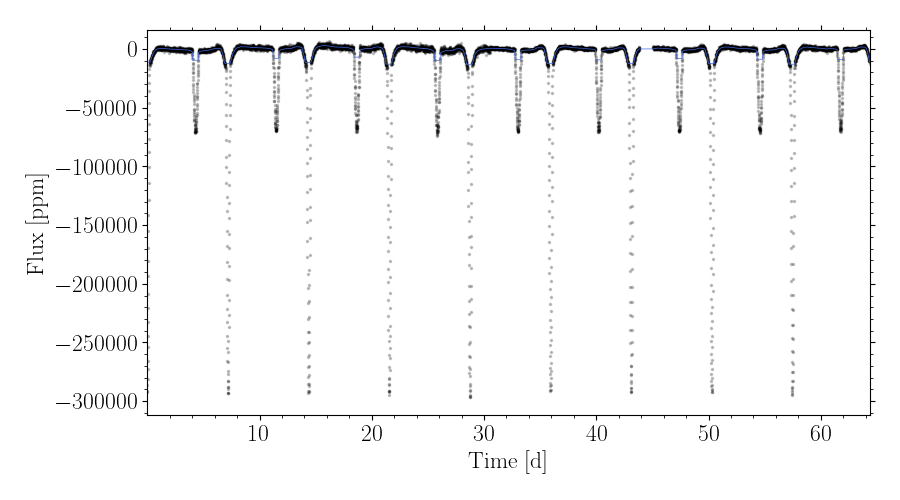

In [8]:
path = '/lhome/nicholas/software/workdir/cs-binary/finals'
star = 'mag085/lc_000000001.ftr'

# In multi mode we parse the entire directory of files
lc = LightCurve(f'{path}/{star}', mode="final")

# Introduce gaps from file
inputFileGap = '/lhome/nicholas/software/workdir/mocka/input/instrumentGAP.tab'
lc.gaps(inputFileGap, replace=True, plot=False);

# Show a quarter light curve
lc.plot(flux_unit='ppm', median_filter=1, input_model=True, legend=False, figsize=(9,5));

<IPython.core.display.Javascript object>


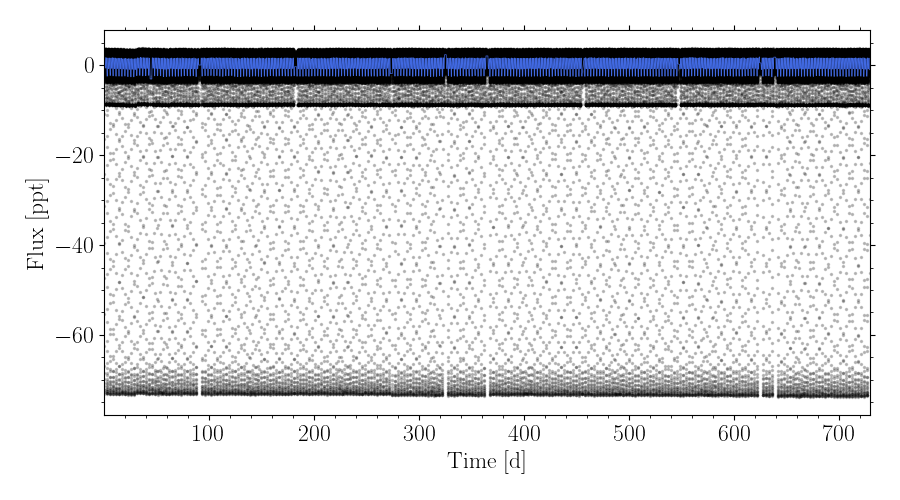

In [183]:
path = '/lhome/nicholas/software/workdir/cs-binary/finals'
star = 'mag085/lc_000000090.ftr'

# In multi mode we parse the entire directory of files
lc = LightCurve(f'{path}/{star}', mode="final")

# Introduce gaps from file
inputFileGap = '/lhome/nicholas/software/workdir/mocka/input/instrumentGAP.tab'
lc.gaps(inputFileGap, replace=True, plot=False);

# Show a quarter light curve
lc.plot(flux_unit='ppt', median_filter=1, input_model=False, legend=False, figsize=(9,5));